# Import libraries

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("Libraries loaded successfully! ☀️")

Libraries loaded successfully! ☀️


# Define NASA POWER API function

In [2]:
def fetch_nasa_solar_data(lat, lon, start, end, country_name):
    """
    Fetch solar data from NASA POWER API
    lat, lon: coordinates
    start, end: format YYYYMMDD
    """
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    
    params = {
        "parameters": "ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,T2M,RH2M,WS2M,PRECTOTCORR",
        "community": "RE",
        "longitude": lon,
        "latitude": lat,
        "start": start,
        "end": end,
        "format": "JSON"
    }
    
    print(f"Fetching data for {country_name}...")
    response = requests.get(url, params=params)
    
    if response.status_code == 200:
        data = response.json()
        properties = data["properties"]["parameter"]
        df = pd.DataFrame(properties)
        df.index = pd.to_datetime(df.index, format="%Y%m%d")
        df["country"] = country_name
        print(f"✅ {country_name} data fetched! Shape: {df.shape}")
        return df
    else:
        print(f"❌ Error: {response.status_code}")
        return None

# Fetch data for 5 countries worldwide

In [3]:
# Define countries with coordinates
countries = [
    {"name": "Ethiopia",     "lat": 9.03,  "lon": 38.74},
    {"name": "Benin",        "lat": 9.31,  "lon": 2.32},
    {"name": "Sierra Leone", "lat": 8.46,  "lon": -11.77},
    {"name": "Germany",      "lat": 51.16, "lon": 10.45},
    {"name": "India",        "lat": 20.59, "lon": 78.96},
]

# Fetch 1 year of data for each country
all_data = {}
for c in countries:
    df = fetch_nasa_solar_data(
        lat=c["lat"],
        lon=c["lon"],
        start="20230101",
        end="20231231",
        country_name=c["name"]
    )
    if df is not None:
        all_data[c["name"]] = df

print(f"\n🌍 Total countries loaded: {len(all_data)}")

Fetching data for Ethiopia...
✅ Ethiopia data fetched! Shape: (365, 7)
Fetching data for Benin...
✅ Benin data fetched! Shape: (365, 7)
Fetching data for Sierra Leone...
✅ Sierra Leone data fetched! Shape: (365, 7)
Fetching data for Germany...
✅ Germany data fetched! Shape: (365, 7)
Fetching data for India...
✅ India data fetched! Shape: (365, 7)

🌍 Total countries loaded: 5


# Look at the data

In [4]:
# Look at Ethiopia data
ethiopia_df = all_data["Ethiopia"]
print("=== ETHIOPIA SOLAR DATA ===")
print(ethiopia_df.head(10))
print(f"\nColumns: {ethiopia_df.columns.tolist()}")
print(f"\nDate range: {ethiopia_df.index.min()} to {ethiopia_df.index.max()}")

=== ETHIOPIA SOLAR DATA ===
            ALLSKY_SFC_SW_DWN  CLRSKY_SFC_SW_DWN    T2M   RH2M  WS2M  \
2023-01-01             4.4582             6.3732  14.21  78.44  3.05   
2023-01-02             4.9486             6.3694  14.64  78.71  3.58   
2023-01-03             6.5952             6.6931  14.01  70.25  3.45   
2023-01-04             6.7800             6.7982  12.91  62.73  2.71   
2023-01-05             6.7937             6.8054  13.50  54.97  2.18   
2023-01-06             6.7560             6.7831  14.46  50.95  2.00   
2023-01-07             6.5150             6.6578  13.88  62.00  2.48   
2023-01-08             6.6115             6.6797  13.90  60.95  2.27   
2023-01-09             6.0410             6.6521  14.60  57.77  2.01   
2023-01-10             5.9311             6.6331  14.34  63.58  2.38   

            PRECTOTCORR   country  
2023-01-01         0.73  Ethiopia  
2023-01-02         0.59  Ethiopia  
2023-01-03         0.30  Ethiopia  
2023-01-04         0.01  Ethiopia  

# Summary statistics

In [5]:
# Summary statistics for all countries
print("=== SUMMARY STATISTICS ===\n")
for country, df in all_data.items():
    print(f"🌍 {country}")
    print(df["ALLSKY_SFC_SW_DWN"].describe())
    print("-" * 40)

=== SUMMARY STATISTICS ===

🌍 Ethiopia
count    365.000000
mean       5.955742
std        0.937321
min        3.129600
25%        5.397100
50%        6.096000
75%        6.610600
max        7.867000
Name: ALLSKY_SFC_SW_DWN, dtype: float64
----------------------------------------
🌍 Benin
count    365.000000
mean       5.218429
std        0.981845
min        1.146000
25%        4.656000
50%        5.413900
75%        5.887900
max        7.153400
Name: ALLSKY_SFC_SW_DWN, dtype: float64
----------------------------------------
🌍 Sierra Leone
count    365.000000
mean       5.046134
std        0.908619
min        2.111500
25%        4.485100
50%        5.096400
75%        5.725900
max        7.362000
Name: ALLSKY_SFC_SW_DWN, dtype: float64
----------------------------------------
🌍 Germany
count    365.000000
mean       2.981893
std        2.135460
min        0.233500
25%        0.985700
50%        2.508000
75%        4.698000
max        8.093500
Name: ALLSKY_SFC_SW_DWN, dtype: float64
-----

# Quick visualization

C:\Users\Eya\AppData\Local\Temp\ipykernel_10320\2152884260.py:12: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Eya\Desktop\solar_analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


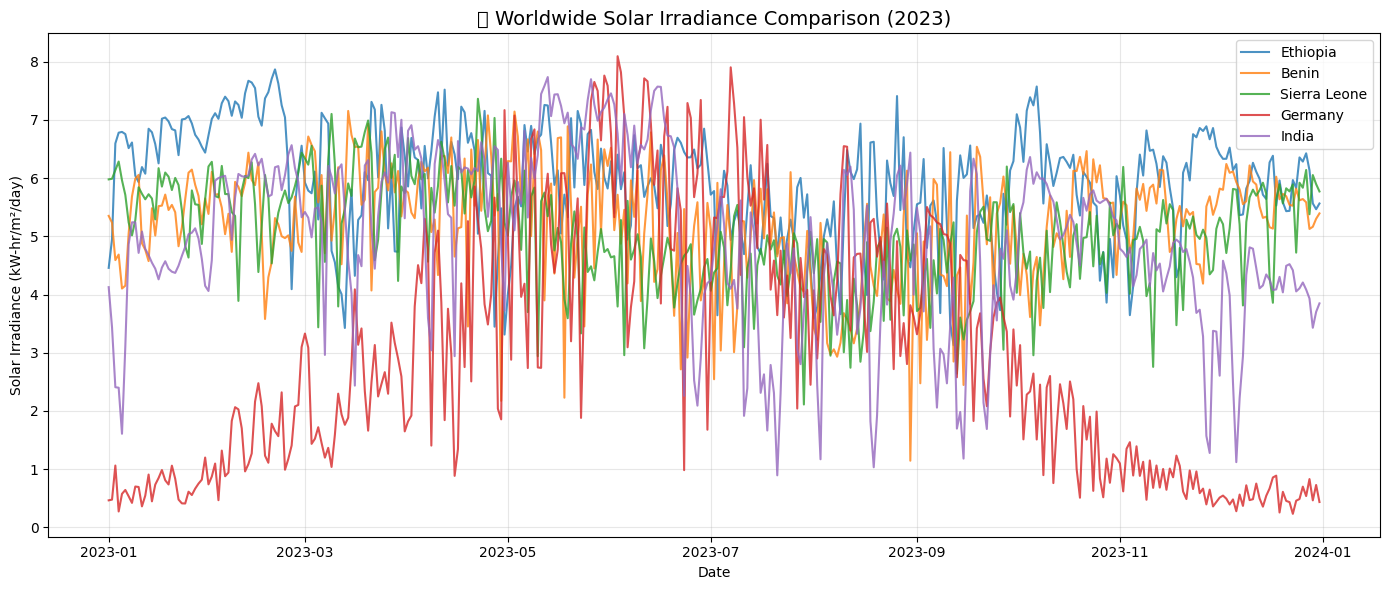

In [6]:
# Plot solar irradiance for all countries
plt.figure(figsize=(14, 6))

for country, df in all_data.items():
    plt.plot(df.index, df["ALLSKY_SFC_SW_DWN"], label=country, alpha=0.8)

plt.title("🌍 Worldwide Solar Irradiance Comparison (2023)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Solar Irradiance (kW-hr/m²/day)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save cleaned data

In [7]:
import os
os.makedirs("../data", exist_ok=True)

for country, df in all_data.items():
    filename = f"../data/{country.lower().replace(' ', '_')}_solar.csv"
    df.to_csv(filename)
    print(f"✅ Saved: {filename}")

print("\n🎉 All data saved successfully!")

✅ Saved: ../data/ethiopia_solar.csv
✅ Saved: ../data/benin_solar.csv
✅ Saved: ../data/sierra_leone_solar.csv
✅ Saved: ../data/germany_solar.csv
✅ Saved: ../data/india_solar.csv

🎉 All data saved successfully!


# Beautiful Country Comparison Chart

C:\Users\Eya\AppData\Local\Temp\ipykernel_10320\2059706088.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(data_for_box, labels=all_data.keys(), patch_artist=True)
c:\Users\Eya\Desktop\solar_analysis\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\Eya\AppData\Local\Temp\ipykernel_10320\2059706088.py:62: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  plt.savefig("../data/worldwide_solar_comparison.png", dpi=150, bbox_inches="tight")
c:\Users\Eya\Desktop\solar_analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


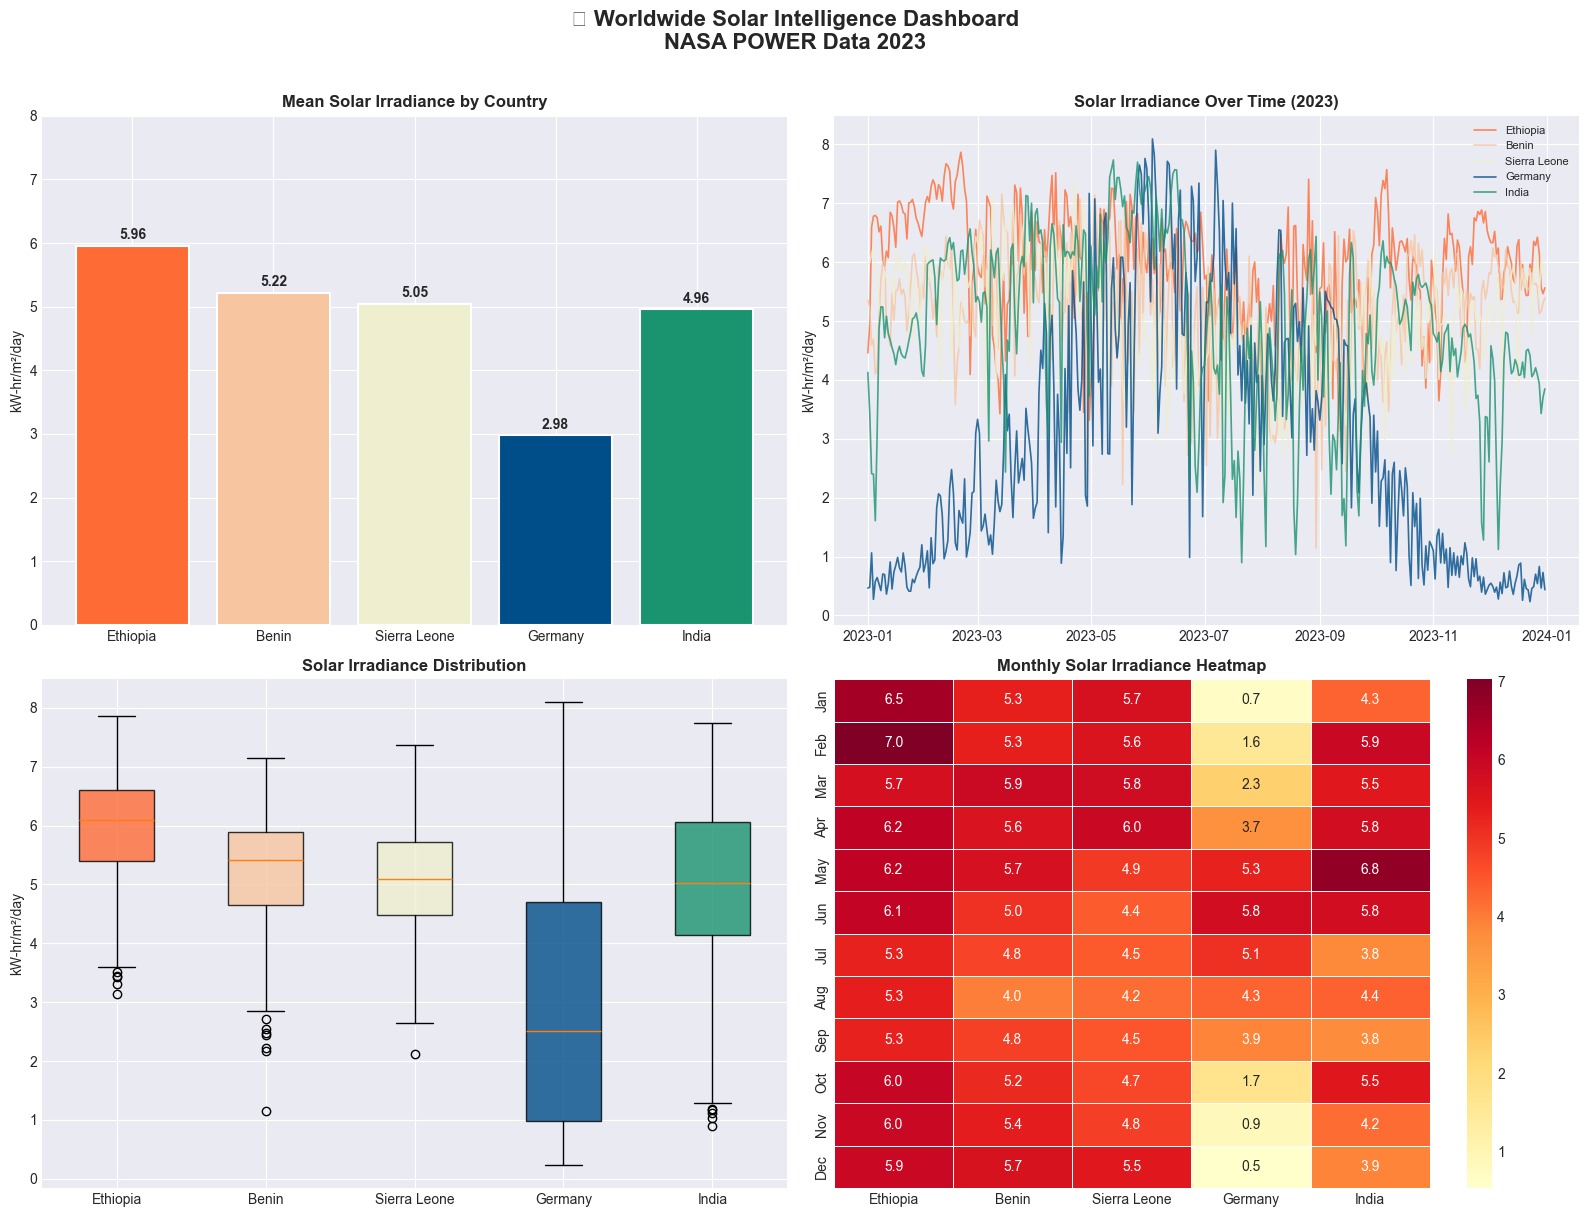

✅ Chart saved!


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Combine all data
combined_df = pd.concat(all_data.values(), ignore_index=False)
combined_df = combined_df.reset_index().rename(columns={"index": "date"})

# Set style
plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("🌍 Worldwide Solar Intelligence Dashboard\nNASA POWER Data 2023", 
             fontsize=16, fontweight="bold", y=1.01)

colors = ["#FF6B35", "#F7C59F", "#EFEFD0", "#004E89", "#1A936F"]

# Plot 1 — Mean Solar Irradiance Bar Chart
ax1 = axes[0, 0]
means = {c: df["ALLSKY_SFC_SW_DWN"].mean() for c, df in all_data.items()}
bars = ax1.bar(means.keys(), means.values(), color=colors, edgecolor="white", linewidth=1.5)
ax1.set_title("Mean Solar Irradiance by Country", fontweight="bold")
ax1.set_ylabel("kW-hr/m²/day")
ax1.set_ylim(0, 8)
for bar, val in zip(bars, means.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.2f}", ha="center", fontweight="bold", fontsize=10)

# Plot 2 — Time Series
ax2 = axes[0, 1]
for (country, df), color in zip(all_data.items(), colors):
    ax2.plot(df.index, df["ALLSKY_SFC_SW_DWN"], 
             label=country, color=color, alpha=0.8, linewidth=1.2)
ax2.set_title("Solar Irradiance Over Time (2023)", fontweight="bold")
ax2.set_ylabel("kW-hr/m²/day")
ax2.legend(fontsize=8)

# Plot 3 — Box Plot
ax3 = axes[1, 0]
data_for_box = [df["ALLSKY_SFC_SW_DWN"].values for df in all_data.values()]
bp = ax3.boxplot(data_for_box, labels=all_data.keys(), patch_artist=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax3.set_title("Solar Irradiance Distribution", fontweight="bold")
ax3.set_ylabel("kW-hr/m²/day")

# Plot 4 — Monthly Average Heatmap
ax4 = axes[1, 1]
monthly_data = {}
for country, df in all_data.items():
    monthly_data[country] = df["ALLSKY_SFC_SW_DWN"].resample("ME").mean().values[:12]

heatmap_df = pd.DataFrame(monthly_data, 
                           index=["Jan","Feb","Mar","Apr","May","Jun",
                                  "Jul","Aug","Sep","Oct","Nov","Dec"])
sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="YlOrRd", 
            ax=ax4, linewidths=0.5)
ax4.set_title("Monthly Solar Irradiance Heatmap", fontweight="bold")

plt.tight_layout()
plt.savefig("../data/worldwide_solar_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved!")